# 01 - Exploratory Data Analysis (EDA)
## Sistem Prediksi Kelulusan Mahasiswa
**UAS Pembelajaran Mesin 2025/2026 - Universitas Dian Nuswantoro**
**Mahasiswa:** Carvin Gildan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Library OK')
print('Pandas :', pd.__version__)
print('NumPy  :', np.__version__)

Library OK
Pandas : 3.0.2
NumPy  : 2.4.4


## 1. Generate Dataset

In [12]:
np.random.seed(42)
N = 1000
ipk = np.clip(np.random.normal(3.0,0.45,N),1.5,4.0).round(2)
sks = np.clip(np.random.normal(120,25,N),20,160).astype(int)
kehadiran = np.clip(np.random.normal(85,10,N),40,100).round(1)
nilai_rata = np.clip(np.random.normal(78,8,N),50,100).round(1)
jumlah_cuti = np.random.poisson(0.3,N)
jumlah_mengulang = np.random.poisson(1.0,N)
lama_studi = np.clip(np.random.normal(8,1.5,N),6,14).astype(int)
penghasilan = np.random.choice(['Rendah','Menengah','Tinggi'],N,p=[0.35,0.45,0.20])
status_kerja = np.random.choice([0,1,2],N,p=[0.6,0.3,0.1])
jalur_masuk = np.random.choice(['SNBP','SNBT','Mandiri'],N,p=[0.3,0.4,0.3])
organisasi = np.random.choice([0,1],N,p=[0.55,0.45])
skor = ((ipk-2.0)*2.2+(sks-100)*0.03+(kehadiran-70)*0.05+(nilai_rata-70)*0.04
        -jumlah_cuti*1.2-jumlah_mengulang*0.9-(lama_studi-8)*0.6
        +organisasi*0.3-(status_kerja==2)*0.8-(status_kerja==1)*0.2
        +np.random.normal(0,1.0,N)-0.9)
lulus = (1/(1+np.exp(-skor))>0.5).astype(int)
df = pd.DataFrame({'ipk':ipk,'sks':sks,'kehadiran':kehadiran,'nilai_rata':nilai_rata,
    'jumlah_cuti':jumlah_cuti,'jumlah_mengulang':jumlah_mengulang,
    'lama_studi_semester':lama_studi,'penghasilan_ortu':penghasilan,
    'status_kerja':status_kerja,'jalur_masuk':jalur_masuk,
    'organisasi':organisasi,'lulus_tepat_waktu':lulus})
os.makedirs('../data/raw',exist_ok=True)
os.makedirs('../data/processed',exist_ok=True)
df.to_csv('../data/raw/dataset_mahasiswa.csv',index=False)
print('Dataset:', df.shape)
print(df['lulus_tepat_waktu'].value_counts().rename({1:'Tepat Waktu',0:'Terlambat'}))

Dataset: (1000, 12)
lulus_tepat_waktu
Tepat Waktu    830
Terlambat      170
Name: count, dtype: int64


## 2. Kualitas Data

In [13]:
print('='*45)
print('KUALITAS DATA')
print('='*45)
print(f'Total baris    : {len(df):,}')
print(f'Total kolom    : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()} (tidak ada)')
print(f'Duplikat       : {df.duplicated().sum()} (tidak ada)')
print()
print(df.dtypes)

KUALITAS DATA
Total baris    : 1,000
Total kolom    : 12
Missing values : 0 (tidak ada)
Duplikat       : 0 (tidak ada)

ipk                    float64
sks                      int64
kehadiran              float64
nilai_rata             float64
jumlah_cuti              int32
jumlah_mengulang         int32
lama_studi_semester      int64
penghasilan_ortu           str
status_kerja             int64
jalur_masuk                str
organisasi               int64
lulus_tepat_waktu        int64
dtype: object


## 3. Distribusi Kelas Target

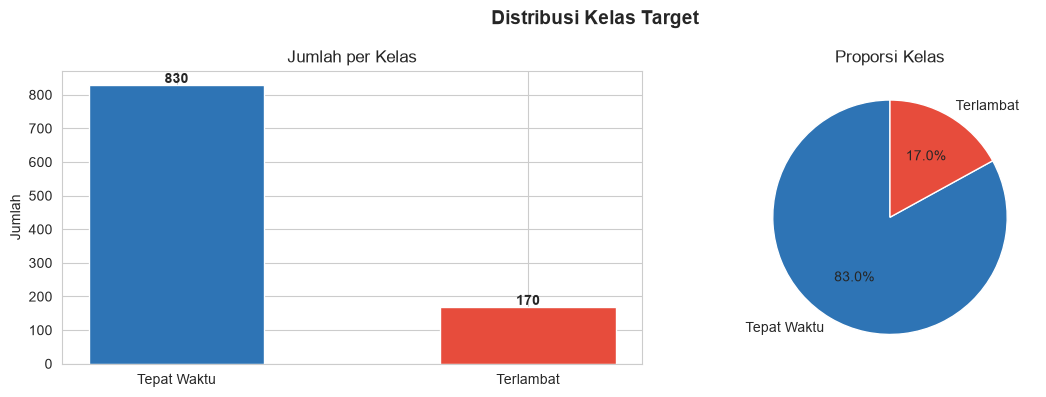

Imbalanced data -> akan ditangani SMOTE


In [14]:
df['Status'] = df['lulus_tepat_waktu'].map({1:'Tepat Waktu',0:'Terlambat'})
counts = df['Status'].value_counts()
fig, axes = plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Distribusi Kelas Target',fontsize=14,fontweight='bold')
axes[0].bar(counts.index,counts.values,color=['#2E74B5','#E74C3C'],edgecolor='white',width=0.5)
axes[0].set_title('Jumlah per Kelas'); axes[0].set_ylabel('Jumlah')
for i,(idx,v) in enumerate(counts.items()):
    axes[0].text(i,v+5,str(v),ha='center',fontweight='bold')
axes[1].pie(counts.values,labels=counts.index,autopct='%1.1f%%',
            colors=['#2E74B5','#E74C3C'],startangle=90)
axes[1].set_title('Proporsi Kelas')
plt.tight_layout()
plt.savefig('../data/processed/eda_1_target.png',dpi=150,bbox_inches='tight')
plt.show()
print('Imbalanced data -> akan ditangani SMOTE')

## 4. Statistik Deskriptif

In [15]:
NUM = ['ipk','sks','kehadiran','nilai_rata','jumlah_cuti','jumlah_mengulang','lama_studi_semester']
print('STATISTIK DESKRIPTIF')
print('='*60)
print(df[NUM].describe().round(2).to_string())

STATISTIK DESKRIPTIF
           ipk      sks  kehadiran  nilai_rata  jumlah_cuti  jumlah_mengulang  lama_studi_semester
count  1000.00  1000.00    1000.00     1000.00      1000.00           1000.00              1000.00
mean      3.01   120.63      84.77       77.84         0.30              0.97                 7.62
std       0.43    23.70       9.24        8.19         0.53              0.92                 1.40
min       1.54    46.00      54.80       54.60         0.00              0.00                 6.00
25%       2.71   104.00      78.50       72.10         0.00              0.00                 6.00
50%       3.01   121.00      85.00       78.00         0.00              1.00                 7.00
75%       3.29   138.00      91.62       83.32         1.00              1.00                 9.00
max       4.00   160.00     100.00      100.00         3.00              5.00                13.00


## 5. Distribusi Fitur Numerik

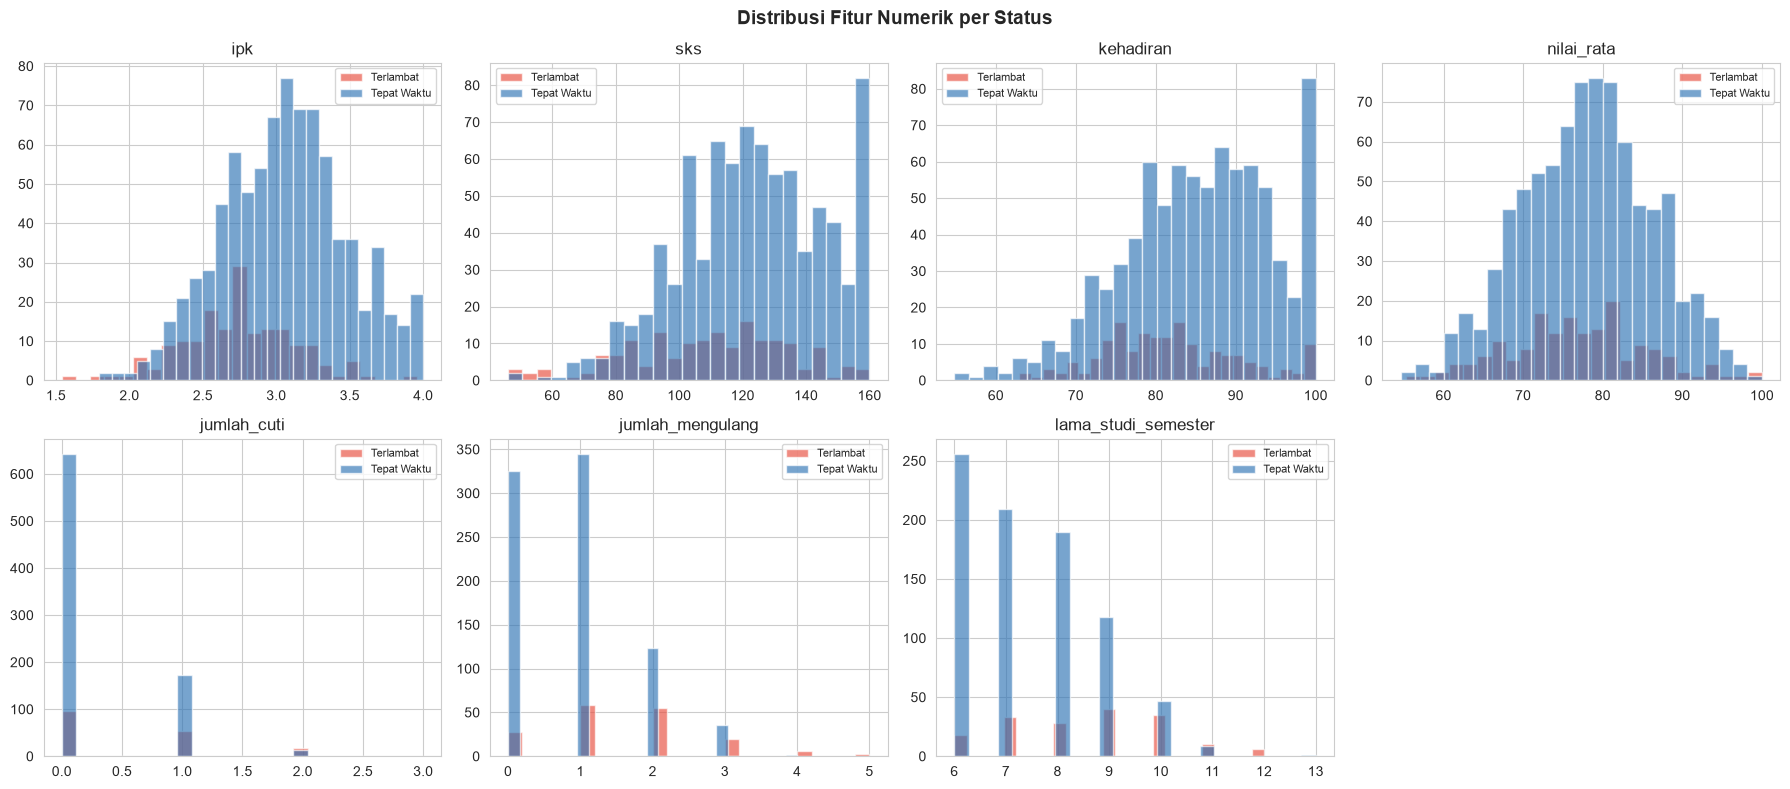

In [16]:
fig, axes = plt.subplots(2,4,figsize=(18,8))
fig.suptitle('Distribusi Fitur Numerik per Status',fontsize=14,fontweight='bold')
axes = axes.flatten()
for i,col in enumerate(NUM):
    for label,color in [('Terlambat','#E74C3C'),('Tepat Waktu','#2E74B5')]:
        axes[i].hist(df[df['Status']==label][col],bins=25,alpha=0.65,
                     color=color,label=label,edgecolor='white')
    axes[i].set_title(col); axes[i].legend(fontsize=8)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../data/processed/eda_2_distribusi.png',dpi=150,bbox_inches='tight')
plt.show()

## 6. Deteksi Outlier (IQR)

In [17]:
print('DETEKSI OUTLIER - Metode IQR')
print('='*55)
for col in NUM:
    Q1,Q3 = df[col].quantile(0.25),df[col].quantile(0.75)
    IQR = Q3-Q1
    n = ((df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)).sum()
    print(f'  {col:<30} Outlier: {n} ({n/len(df)*100:.1f}%)')

DETEKSI OUTLIER - Metode IQR
  ipk                            Outlier: 4 (0.4%)
  sks                            Outlier: 6 (0.6%)
  kehadiran                      Outlier: 4 (0.4%)
  nilai_rata                     Outlier: 2 (0.2%)
  jumlah_cuti                    Outlier: 2 (0.2%)
  jumlah_mengulang               Outlier: 65 (6.5%)
  lama_studi_semester            Outlier: 0 (0.0%)


## 7. Heatmap Korelasi

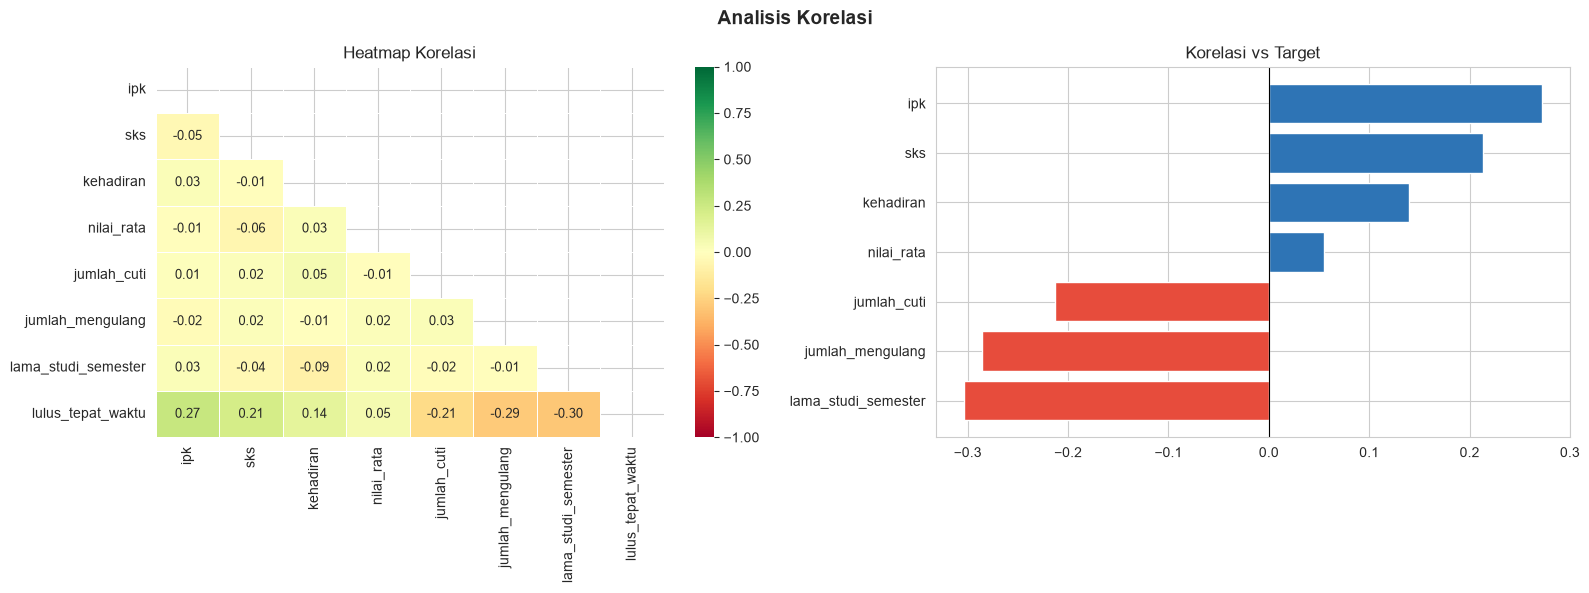

Korelasi vs Target:
  ipk                            +0.272
  sks                            +0.213
  kehadiran                      +0.140
  nilai_rata                     +0.055
  jumlah_cuti                    -0.213
  jumlah_mengulang               -0.285
  lama_studi_semester            -0.303


In [18]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Analisis Korelasi',fontsize=14,fontweight='bold')
corr = df[NUM+['lulus_tepat_waktu']].corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlGn',mask=mask,
            vmin=-1,vmax=1,ax=axes[0],linewidths=0.5,annot_kws={'size':9})
axes[0].set_title('Heatmap Korelasi')
corr_target = corr['lulus_tepat_waktu'].drop('lulus_tepat_waktu').sort_values()
clr = ['#E74C3C' if v<0 else '#2E74B5' for v in corr_target]
axes[1].barh(corr_target.index,corr_target.values,color=clr,edgecolor='white')
axes[1].set_title('Korelasi vs Target'); axes[1].axvline(0,color='black',lw=0.8)
plt.tight_layout()
plt.savefig('../data/processed/eda_3_korelasi.png',dpi=150,bbox_inches='tight')
plt.show()
print('Korelasi vs Target:')
for f,v in corr_target.sort_values(ascending=False).items():
    print(f'  {f:<30} {v:+.3f}')

## 8. Fitur Kategorik

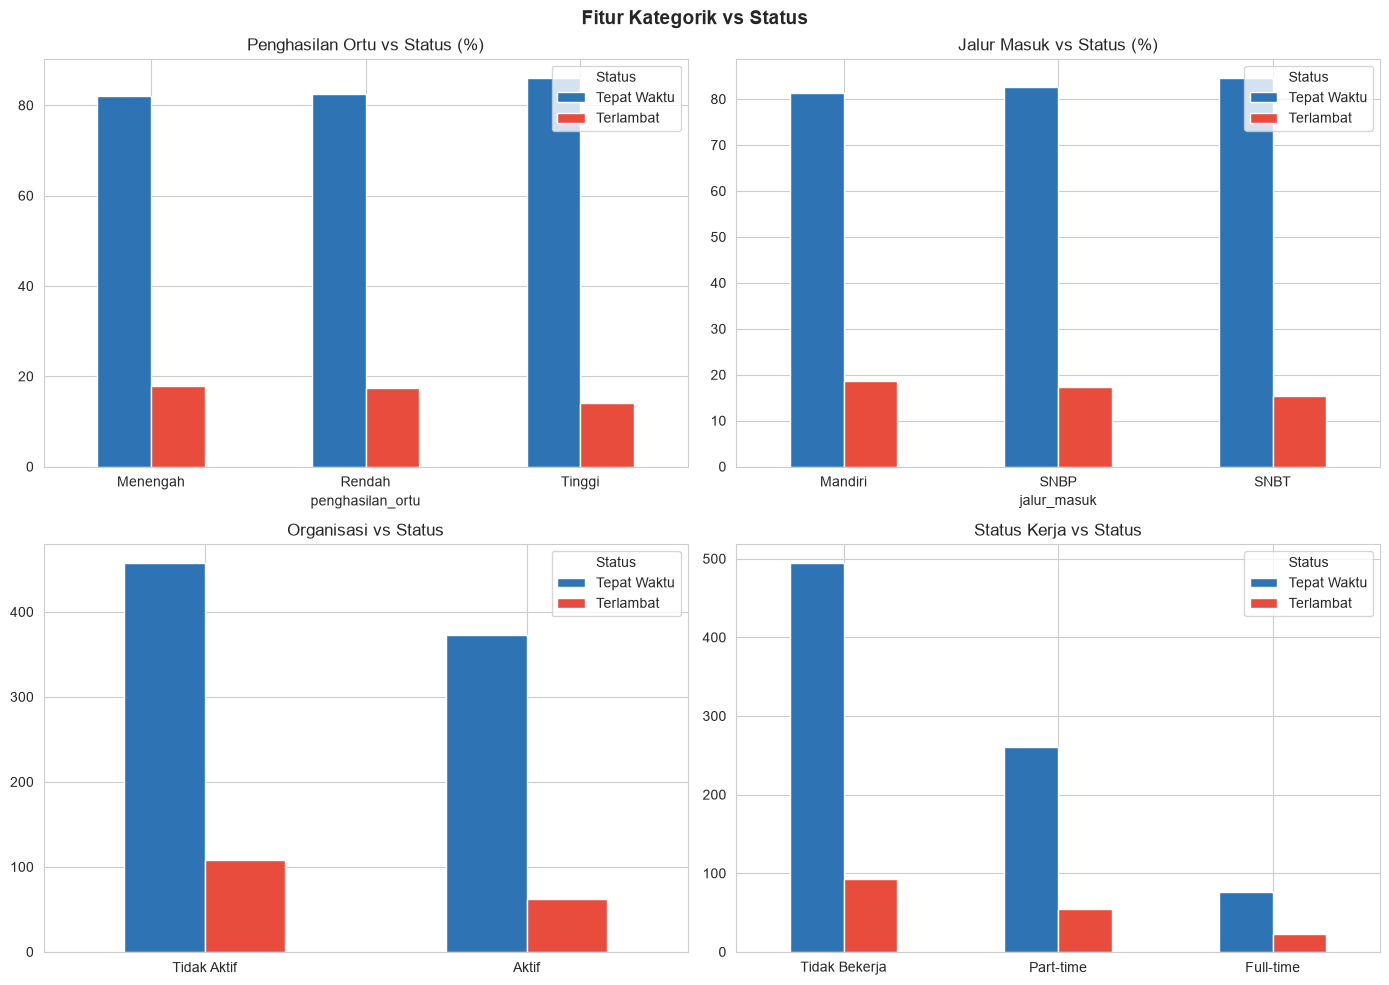

In [19]:
fig,axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Fitur Kategorik vs Status',fontsize=14,fontweight='bold')
pd.crosstab(df['penghasilan_ortu'],df['Status'],normalize='index').mul(100).plot(
    kind='bar',ax=axes[0,0],color=['#2E74B5','#E74C3C'],edgecolor='white',rot=0)
axes[0,0].set_title('Penghasilan Ortu vs Status (%)')
pd.crosstab(df['jalur_masuk'],df['Status'],normalize='index').mul(100).plot(
    kind='bar',ax=axes[0,1],color=['#2E74B5','#E74C3C'],edgecolor='white',rot=0)
axes[0,1].set_title('Jalur Masuk vs Status (%)')
org=df.groupby(['organisasi','Status']).size().unstack(fill_value=0)
org.index=['Tidak Aktif','Aktif']
org.plot(kind='bar',ax=axes[1,0],color=['#2E74B5','#E74C3C'],edgecolor='white',rot=0)
axes[1,0].set_title('Organisasi vs Status')
kerja=df.groupby(['status_kerja','Status']).size().unstack(fill_value=0)
kerja.index=['Tidak Bekerja','Part-time','Full-time']
kerja.plot(kind='bar',ax=axes[1,1],color=['#2E74B5','#E74C3C'],edgecolor='white',rot=0)
axes[1,1].set_title('Status Kerja vs Status')
plt.tight_layout()
plt.savefig('../data/processed/eda_4_kategorik.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Boxplot

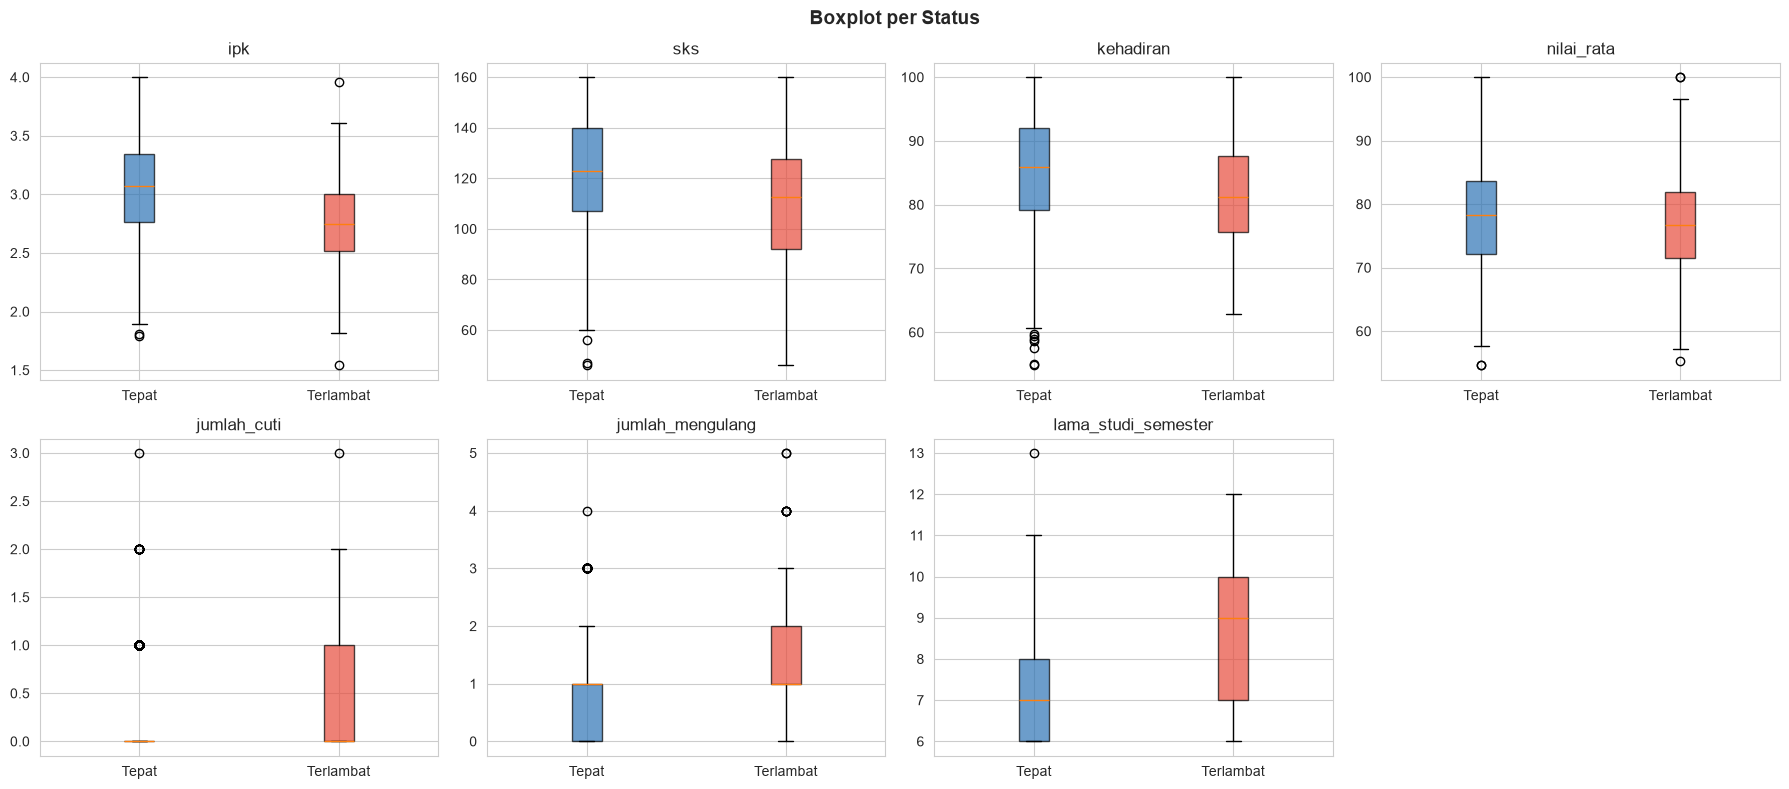

In [20]:
fig,axes = plt.subplots(2,4,figsize=(18,8))
fig.suptitle('Boxplot per Status',fontsize=14,fontweight='bold')
axes=axes.flatten()
for i,col in enumerate(NUM):
    bp=axes[i].boxplot([df[df['Status']=='Tepat Waktu'][col],
                        df[df['Status']=='Terlambat'][col]],
                        patch_artist=True, tick_labels=['Tepat','Terlambat']) # <--- DIGANTI DI SINI
    bp['boxes'][0].set_facecolor('#2E74B5'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#E74C3C'); bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../data/processed/eda_5_boxplot.png',dpi=150,bbox_inches='tight')
plt.show()

## 10. Ringkasan 5 Insight Penting

In [21]:
tw = df[df['lulus_tepat_waktu']==1]
tl = df[df['lulus_tepat_waktu']==0]
print('5 INSIGHT PENTING DARI EDA')
print('='*55)
print('1. IPK')
print('   Tepat Waktu rata-rata:', round(tw['ipk'].mean(),2))
print('   Terlambat rata-rata  :', round(tl['ipk'].mean(),2))
print('   Selisih              :', round(tw['ipk'].mean()-tl['ipk'].mean(),2), 'poin')
print()
print('2. Kehadiran')
print('   Tepat Waktu:', round(tw['kehadiran'].mean(),1),'%')
print('   Terlambat  :', round(tl['kehadiran'].mean(),1),'%')
print()
print('3. Status Kerja')
print('   Full-time  tepat waktu:', round(df[df['status_kerja']==2]['lulus_tepat_waktu'].mean()*100),'%')
print('   Tidak kerja tepat waktu:', round(df[df['status_kerja']==0]['lulus_tepat_waktu'].mean()*100),'%')
print()
print('4. Jalur Masuk')
for jalur in ['SNBP','SNBT','Mandiri']:
    pct = df[df['jalur_masuk']==jalur]['lulus_tepat_waktu'].mean()*100
    print(f'   {jalur}: {pct:.0f}% tepat waktu')
print()
print('5. Jumlah Mengulang MK')
print('   Lebih 3 MK diulang  :', round(df[df['jumlah_mengulang']>3]['lulus_tepat_waktu'].mean()*100),'% tepat waktu')
print('   Max 3 MK diulang    :', round(df[df['jumlah_mengulang']<=3]['lulus_tepat_waktu'].mean()*100),'% tepat waktu')
print()
print('EDA selesai! Lanjut ke 02_modeling.ipynb')

5 INSIGHT PENTING DARI EDA
1. IPK
   Tepat Waktu rata-rata: 3.06
   Terlambat rata-rata  : 2.75
   Selisih              : 0.31 poin

2. Kehadiran
   Tepat Waktu: 85.4 %
   Terlambat  : 81.9 %

3. Status Kerja
   Full-time  tepat waktu: 77 %
   Tidak kerja tepat waktu: 84 %

4. Jalur Masuk
   SNBP: 83% tepat waktu
   SNBT: 85% tepat waktu
   Mandiri: 81% tepat waktu

5. Jumlah Mengulang MK
   Lebih 3 MK diulang  : 11 % tepat waktu
   Max 3 MK diulang    : 84 % tepat waktu

EDA selesai! Lanjut ke 02_modeling.ipynb
